In [1]:
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
jr.init_cluster()

#parameters
nx = 256
ny = 256
nz = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 0.1
t_end = 6.0
cfl_safety = 1.0 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/orzag-tang-3D_v2/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)


#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
psi = (jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)) * jnp.cos(z_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock))

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 1


nblock estimate: 8


In [2]:
jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,shardings=shardings)

Saving initial state as snapshot 0
0.08986529981193361
0.17919877922183053
Saving snapshot 1
0.267794304771358
0.3554868259292001
Saving snapshot 2
0.4419335738782202
0.5257582216155494
Saving snapshot 3
0.6062411514223319
0.6831298850297856
Saving snapshot 4
0.7564541077767916
0.826441144783016
Saving snapshot 5
0.8934011027081895
0.9575058312967152
Saving snapshot 6
1.01905616637939
1.0783134324049162
Saving snapshot 7
1.1355860078433997
1.191290491333905
Saving snapshot 8
1.2458223458566065
1.2994995558584082
Saving snapshot 9
1.352614899198309
1.4054191220827241
Saving snapshot 10
1.4581210690833566
1.5108561458379375
Saving snapshot 11
1.5637539628391004
1.616880500402043
Saving snapshot 12
1.6702874928837317
1.7237849313523468
Saving snapshot 13
1.7767689809789835
1.8291632486112888
Saving snapshot 14
1.8809012635788993
1.931872925242262
Saving snapshot 15
1.9818683150370684
2.0304817010529237
2.0774687340127036
Saving snapshot 16
2.122967168810785
2.1673515723466528
2.2110546753

'Ending simulation at t = 6.000411552152522. It took 2311.386674749898s'

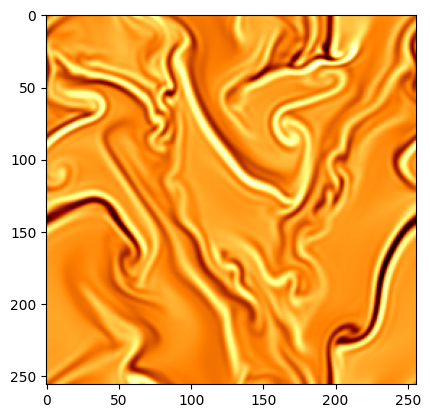

In [4]:
f=sn.load_slice(48,64,1,snap_path,item="fields.phik")
vort=ft.irfft2(-kgrid.ksq()*f)
plt.imshow(vort[0,:,:],cmap='afmhot')

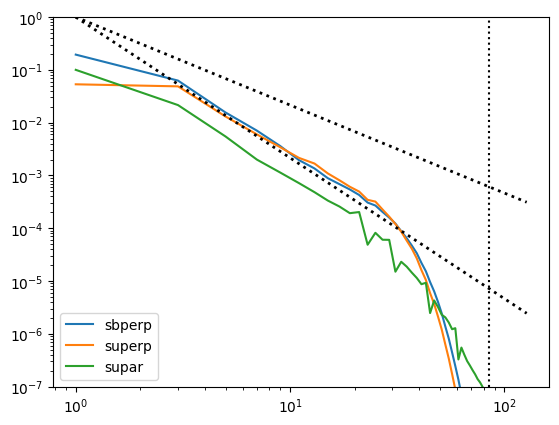

In [5]:
sk=sn.load_snapshot(48,mngr,params,shardings)
bin_factor=2
bins,su,sb=diag.perpspec(sk,kgrid,params,bin_factor=bin_factor)
plt.loglog(bins,sb,label='sbperp')
plt.loglog(bins,su,label='superp')
plt.ylim(1e-7,1)
plt.loglog(bins,bins**(-5.0/3.0),'k:',linewidth=2)
plt.loglog(bins,bins**(-8.0/3.0),'k:',linewidth=2)
plt.loglog([params.nx//3,params.nx//3],[1e-7,1],'k:')
binsz,suz,sbz=diag.parspec(sk,kgrid,params,bin_factor)
plt.loglog(binsz,suz,label='supar')
#plt.loglog(kz,kz**(-5/3))
plt.legend()


In [ ]:
sk=sn.load_snapshot(48,mngr,params,shardings)
vort = ft.irfft2(-kgrid.ksq()*sk.fields.phik)
plt.subplot(121)
plt.imshow(vort[0,:,:])
plt.subplot(122)
plt.imshow(vort[:,0,:])
plt.savefig(snap_path+str(isnap).zfill(3)+".png")
plt.close('all')

In [6]:
#Making some snapshots.
for isnap in range(0,49):
    snap=sn.load_snapshot(isnap,mngr,params,shardings)
    #vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    #vsq=jnp.sum(jnp.array(jax.tree_util.tree_map(lambda gfk: ft.irfft2(gfk),gradk(snap.fields.phik,kgrid)))**2.0,axis=0)
    vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    plt.subplot(121)
    plt.imshow(vort[64,:,:],vmin=-30,vmax=30,cmap="afmhot")
    plt.subplot(122)
    plt.imshow(vort[:,0,:],vmin=-30,vmax=30,cmap="afmhot")
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')
    

In [7]:
isnap=48
snap=sn.load_snapshot(isnap,mngr,params,shardings)
vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
for iz in range(nz):
    plt.imshow(vort[iz,:,:],cmap="afmhot")
    plt.savefig(snap_path+"slice"+str(iz).zfill(3)+".png")
    plt.close('all')

In [8]:
def perpspec_slice(phik,kgrid,params,bin_factor=2.0):
    rfft2_y_factor = jnp.full(phik.shape[-1],2.0)
    rfft2_y_factor = rfft2_y_factor.at[0].set(1.0)
    rfft2_y_factor = rfft2_y_factor.at[-1].set(1.0)
    energy_u = 0.5 * kgrid.ksq() * jnp.abs(phik)**2.0 * rfft2_y_factor
    kunit = min(2 * jnp.pi / params.Lx, 2 * jnp.pi / params.Ly)
    kmax = min(params.nx//2,params.ny//2)*kunit
    dk=kunit*bin_factor
    bin_edges = jnp.arange(0,kmax+dk,dk)
    norm = 1 / float(params.nx*params.ny)**2
    spec_u, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bin_edges,weights=energy_u*norm/dk)
    #spec_u, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_u*norm)
    #spec_b, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_b*norm)
    bin_centers=(bin_edges[1:] + bin_edges[:-1]) / 2
    return bin_centers,spec_u

(1e-07, 1)

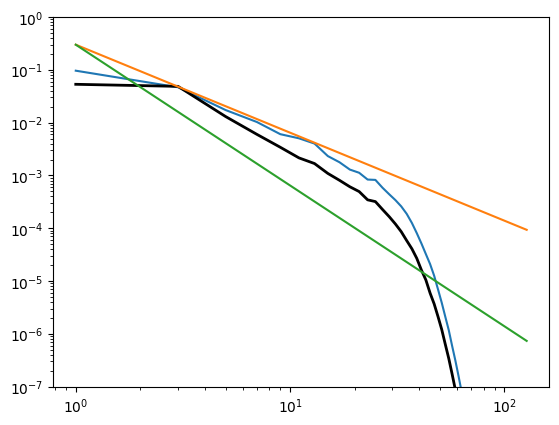

In [10]:
ss=[]
for iz in range(nz):
    f=sn.load_slice(48,iz,1,snap_path,'fields.phik')
    b,s=perpspec_slice(f[0,:,:],kgrid,params,bin_factor=2)
    if iz==64:
        plt.loglog(b,s)
    ss.append(s)
ssum=jnp.sum(jnp.array(ss),axis=0)/nz
plt.loglog(b,ssum,'k',linewidth=2)
plt.loglog(b,0.3*b**-(5/3))
plt.loglog(b,0.3*b**-(8/3))
plt.ylim(1e-7,1)

(1, 256, 129)